# Curva ROC y AUC (muy sencillo)

### Interpretación general
- La curva ROC nos dice cómo cambia el modelo cuando movemos el umbral.
- El AUC resume todo en un solo número:
  - cercano a 1.0: muy buen modelo
  - cercano a 0.5: similar a adivinar
  - menor a 0.5: está ordenando mal las clases

In [ ]:
# Paso 0: importar librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Si no tienes scikit-learn, puedes instalarla con:
# !pip install scikit-learn

## 1) Datos de ejemplo

- `y_real`: la clase verdadera (0 o 1).
- `y_score`: probabilidad estimada de pertenecer a clase 1.

Usaremos pocos datos para que sea fácil seguir los cálculos.

### Interpretación
- Si `y_score` es alto, el modelo "confía" más en que ese caso es clase 1.
- Si `y_score` es bajo, el modelo cree más que es clase 0.

In [ ]:
# Datos muy pequeños (didácticos)
y_real = np.array([0, 0, 1, 1, 0, 1, 0, 1])
y_score = np.array([0.10, 0.40, 0.35, 0.80, 0.20, 0.70, 0.60, 0.90])

df = pd.DataFrame({"y_real": y_real, "y_score": y_score})
df

,y_real,y_score
0,0,0.10
1,0,0.40
2,1,0.35
3,1,0.80
4,0,0.20
5,1,0.70
6,0,0.60
7,1,0.90


## 2) ¿Cómo se construye la ROC?

Para cada **umbral** (`threshold`):

1. Convertimos probabilidades a clases:
   - predice 1 si `y_score >= threshold`
2. Calculamos:
   - **TPR** = VP / (VP + FN)  (sensibilidad o recall)
   - **FPR** = FP / (FP + VN)

La curva ROC grafica `TPR` (eje y) contra `FPR` (eje x).

### ¿Qué significan VP, FN, FP y VN?
- **VP (verdaderos positivos):** casos que sí eran clase 1 y el modelo predijo 1.
- **FN (falsos negativos):** casos que sí eran clase 1, pero el modelo predijo 0.
- **FP (falsos positivos):** casos que eran clase 0, pero el modelo predijo 1.
- **VN (verdaderos negativos):** casos que eran clase 0 y el modelo predijo 0.

### ¿Cómo interpretar TPR y FPR?
- **TPR** responde: "De todos los positivos reales, ¿cuántos detecté bien?"
- **FPR** responde: "De todos los negativos reales, ¿a cuántos marqué mal como positivos?"

En palabras simples:
- Queremos **TPR alto** (detectar muchos positivos reales).
- Queremos **FPR bajo** (cometer pocos falsos positivos).

### Interpretación del umbral
- Si el umbral es **alto** (por ejemplo 0.90), el modelo es más estricto para decir "positivo".
  - Suele haber menos FP, pero también puede perder positivos reales (más FN).
- Si el umbral es **bajo** (por ejemplo 0.30), el modelo dice "positivo" con más facilidad.
  - Suele detectar más positivos (sube TPR), pero también aumenta falsos positivos (sube FPR).

Por eso la ROC muestra un **intercambio beneficio-costo**:
- Beneficio: subir TPR.
- Costo: subir FPR.

### Idea clave de la ROC
Cada punto de la curva representa un umbral distinto. La curva completa nos ayuda a elegir un umbral según el contexto del problema (qué error duele más: falsos positivos o falsos negativos).

In [ ]:
def matriz_confusion_basica(y_real, y_score, threshold):
    """Calcula VP, FN, FP, VN para un umbral dado."""
    y_pred = (y_score >= threshold).astype(int)

    tp = np.sum((y_real == 1) & (y_pred == 1))  # verdaderos positivos
    fn = np.sum((y_real == 1) & (y_pred == 0))  # falsos negativos
    fp = np.sum((y_real == 0) & (y_pred == 1))  # falsos positivos
    tn = np.sum((y_real == 0) & (y_pred == 0))  # verdaderos negativos

    return tp, fn, fp, tn


def calcular_tpr_fpr(y_real, y_score, threshold):
    tp, fn, fp, tn = matriz_confusion_basica(y_real, y_score, threshold)

    # Evitamos divisiones por cero por seguridad
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

    return tpr, fpr


# Ejemplo didáctico: matriz de confusión para un umbral fijo
umbral_ejemplo = 0.50
tp, fn, fp, tn = matriz_confusion_basica(y_real, y_score, umbral_ejemplo)

matriz_df = pd.DataFrame(
    [[tp, fn], [fp, tn]],
    index=["Real: Positivo (1)", "Real: Negativo (0)"],
    columns=["Pred: Positivo (1)", "Pred: Negativo (0)"]
)

print(f"Umbral de ejemplo = {umbral_ejemplo:.2f}")
print("\nMatriz de confusión (filas = clase real, columnas = predicción):")
display(matriz_df)

# Métricas para este umbral de ejemplo
tpr_ej, fpr_ej = calcular_tpr_fpr(y_real, y_score, umbral_ejemplo)
print(f"TPR = {tpr_ej:.2f} = VP/(VP+FN) = {tp}/({tp}+{fn})")
print(f"FPR = {fpr_ej:.2f} = FP/(FP+VN) = {fp}/({fp}+{tn})")

Umbral de ejemplo = 0.50

Matriz de confusión (filas = clase real, columnas = predicción):


,Pred: Positivo (1),Pred: Negativo (0)
Real: Positivo (1),3,1
Real: Negativo (0),1,3


TPR = 0.75 = VP/(VP+FN) = 3/(3+1)
FPR = 0.25 = FP/(FP+VN) = 1/(1+3)


In [ ]:
# Umbrales de mayor a menor para recorrer toda la curva
umbrales = np.sort(np.unique(y_score))[::-1]

# También agregamos extremos para forzar puntos (0,0) y (1,1)
umbrales = np.r_[1.01, umbrales, -0.01]

puntos_roc = []
for u in umbrales:
    tpr, fpr = calcular_tpr_fpr(y_real, y_score, u)
    puntos_roc.append((fpr, tpr, u))

roc_df = pd.DataFrame(puntos_roc, columns=["FPR", "TPR", "Umbral"])
roc_df

,FPR,TPR,Umbral
0,0.00,0.00,1.01
1,0.00,0.25,0.90
2,0.00,0.50,0.80
3,0.00,0.75,0.70
4,0.25,0.75,0.60
5,0.50,0.75,0.40
6,0.50,1.00,0.35
7,0.75,1.00,0.20
8,1.00,1.00,0.10
9,1.00,1.00,-0.01


## 3) Graficar la curva ROC

### Interpretación
- Cada punto representa un umbral distinto.
- En el gráfico pondremos, para cada punto: umbral, TPR y FPR.
- Mientras más cerca esté la curva de la esquina superior izquierda, mejor.

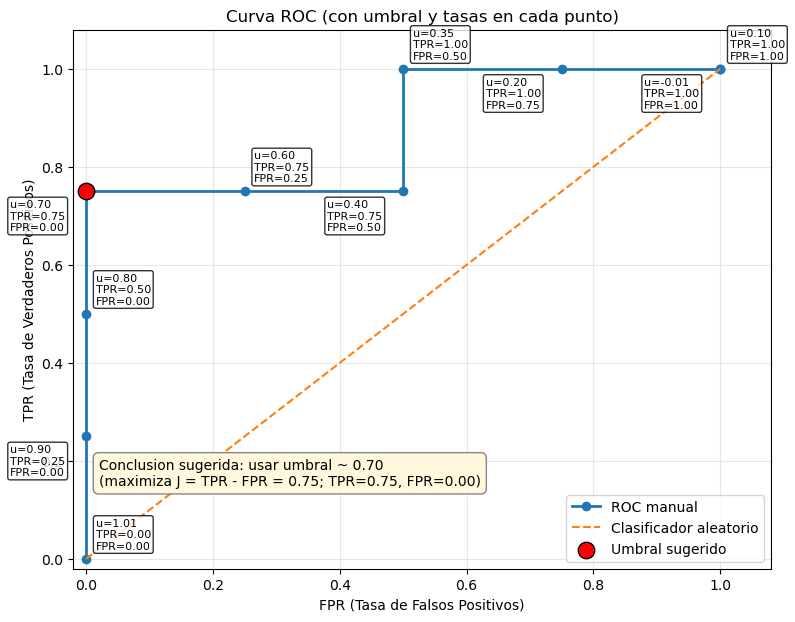

Conclusion sugerida: usar umbral ~ 0.70
(maximiza J = TPR - FPR = 0.75; TPR=0.75, FPR=0.00)
Nota: el umbral final puede cambiar segun el costo real de FP vs FN en tu problema.


In [ ]:
# Ordenamos por FPR para graficar correctamente
roc_ordenado = roc_df.sort_values(["FPR", "TPR"]).reset_index(drop=True)

# --- Selección de umbral sugerido (Youden J = TPR - FPR) ---
# Ignoramos los extremos artificiales (1.01 y -0.01) para elegir un umbral realista.
candidatos = roc_ordenado[(roc_ordenado["Umbral"] <= 1.0) & (roc_ordenado["Umbral"] >= 0.0)].copy()
candidatos["J"] = candidatos["TPR"] - candidatos["FPR"]
mejor = candidatos.loc[candidatos["J"].idxmax()]

umbral_optimo = mejor["Umbral"]
tpr_optimo = mejor["TPR"]
fpr_optimo = mejor["FPR"]
j_optimo = mejor["J"]

plt.figure(figsize=(9, 7))
plt.plot(roc_ordenado["FPR"], roc_ordenado["TPR"], marker="o", label="ROC manual", linewidth=2)
plt.plot([0, 1], [0, 1], "--", label="Clasificador aleatorio")

# Etiquetas en cada punto: umbral, TPR y FPR
for i, fila in roc_ordenado.iterrows():
    texto = f"u={fila['Umbral']:.2f}\nTPR={fila['TPR']:.2f}\nFPR={fila['FPR']:.2f}"
    dx = 0.015 if i % 2 == 0 else -0.12
    dy = 0.02 if i % 2 == 0 else -0.08
    plt.annotate(
        texto,
        (fila["FPR"], fila["TPR"]),
        xytext=(fila["FPR"] + dx, fila["TPR"] + dy),
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8)
    )

# Resaltamos el umbral sugerido
plt.scatter([fpr_optimo], [tpr_optimo], s=140, c="red", edgecolors="black", zorder=5, label="Umbral sugerido")

conclusion = (
    f"Conclusion sugerida: usar umbral ~ {umbral_optimo:.2f}\n"
    f"(maximiza J = TPR - FPR = {j_optimo:.2f}; TPR={tpr_optimo:.2f}, FPR={fpr_optimo:.2f})"
)

# Caja de texto de conclusion dentro del grafico
plt.text(
    0.02,
    0.15,
    conclusion,
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.4", fc="#fff8dc", ec="gray", alpha=0.95)
)

plt.title("Curva ROC (con umbral y tasas en cada punto)")
plt.xlabel("FPR (Tasa de Falsos Positivos)")
plt.ylabel("TPR (Tasa de Verdaderos Positivos)")
plt.xlim(-0.02, 1.08)
plt.ylim(-0.02, 1.08)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(conclusion)
print("Nota: el umbral final puede cambiar segun el costo real de FP vs FN en tu problema.")

## 4) Calcular AUC manualmente

El AUC es el área bajo la curva ROC. Usaremos la **regla del trapecio** (`np.trapz`).

### Interpretación
- AUC es la probabilidad de que un positivo tenga score mayor que un negativo.
- Regla rápida:
  - AUC ~ 0.5: desempeño pobre/aleatorio.
  - AUC entre 0.7 y 0.8: aceptable.
  - AUC > 0.8: bueno.

In [ ]:
# AUC manual con trapecios
auc_manual = np.trapz(roc_ordenado["TPR"], roc_ordenado["FPR"])
print(f"AUC manual = {auc_manual:.4f}")

if auc_manual >= 0.9:
    print("Interpretación: excelente capacidad de separación.")
elif auc_manual >= 0.8:
    print("Interpretación: buena capacidad de separación.")
elif auc_manual >= 0.7:
    print("Interpretación: capacidad aceptable.")
elif auc_manual >= 0.5:
    print("Interpretación: capacidad baja, cercana a aleatoria.")
else:
    print("Interpretación: peor que aleatorio (revisar scores o etiquetas).")

AUC manual = 0.8750
Interpretación: buena capacidad de separación.
